# 04 · Model Evaluation & Comparison
**Owner:** Solo Evaluator (TBD)  
**Environment:** Local Anaconda (no GPU needed — models are pre-trained)  
**Depends on:**  
- `data/processed/X_test.npy`, `y_test.npy` from notebook 00  
- `models/lstm/lstm_metrics.json` from notebook 01  
- `models/gru/gru_metrics.json` from notebook 02  
- `models/bilstm/bilstm_metrics.json` from notebook 03  

**Outputs:**  
- `evaluation/comparison_results.csv`  
- `evaluation/roc_comparison.png`  
- `evaluation/confusion_matrices.png`  
- `evaluation/report_summary.md`

---
> Run this notebook **only after all three pairs have completed training and saved their metrics.**

In [1]:
## ── 0. Environment ────────────────────────────────────────────────────────
import os, json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

IN_COLAB = os.path.exists('/content')
if IN_COLAB:
    from google.colab import drive; drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/FraudGuard_Parent'
else:
    BASE = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

DATA_PROC = os.path.join(BASE, 'data',   'processed')
EVAL_DIR  = os.path.join(BASE, 'evaluation')
os.makedirs(EVAL_DIR, exist_ok=True)

import tensorflow as tf
print("TF:", tf.__version__)

Mounted at /content/drive
TF: 2.20.0


In [2]:
## ── 1. Load test data & all models ───────────────────────────────────────
X_test = np.load(os.path.join(DATA_PROC, 'X_test.npy'))
y_test = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

models_info = {
    'LSTM'  : os.path.join(BASE, 'models', 'lstm',   'lstm_model.keras'),
    'GRU'   : os.path.join(BASE, 'models', 'gru',    'gru_model.keras'),
    'BiLSTM': os.path.join(BASE, 'models', 'bilstm', 'bilstm_model.keras'),
}
metrics_paths = {
    'LSTM'  : os.path.join(BASE, 'models', 'lstm',   'lstm_metrics.json'),
    'GRU'   : os.path.join(BASE, 'models', 'gru',    'gru_metrics.json'),
    'BiLSTM': os.path.join(BASE, 'models', 'bilstm', 'bilstm_metrics.json'),
}

trained_models = {}
all_metrics    = {}

for name, mpath in models_info.items():
    if os.path.exists(mpath):
        trained_models[name] = tf.keras.models.load_model(mpath)
        print(f"Loaded {name} from {mpath}")
    else:
        print(f"WARNING: {name} model not found at {mpath}")

for name, jpath in metrics_paths.items():
    if os.path.exists(jpath):
        with open(jpath) as f:
            all_metrics[name] = json.load(f)
    else:
        print(f"WARNING: {name} metrics not found")

Loaded LSTM from /content/drive/MyDrive/FraudGuard_Parent/models/lstm/lstm_model.keras
Loaded GRU from /content/drive/MyDrive/FraudGuard_Parent/models/gru/gru_model.keras
Loaded BiLSTM from /content/drive/MyDrive/FraudGuard_Parent/models/bilstm/bilstm_model.keras


In [3]:
## ── 2. Generate predictions for all models ───────────────────────────────
from sklearn.metrics import roc_auc_score, roc_curve

THRESHOLD = 0.45
y_probs = {}
y_preds = {}

for name, model in trained_models.items():
    prob = model.predict(X_test, batch_size=256, verbose=0).flatten()
    y_probs[name] = prob
    y_preds[name] = (prob >= THRESHOLD).astype(int)
    print(f"{name} — AUC: {roc_auc_score(y_test, prob):.4f}")

LSTM — AUC: 0.8305
GRU — AUC: 0.8323
BiLSTM — AUC: 0.8182


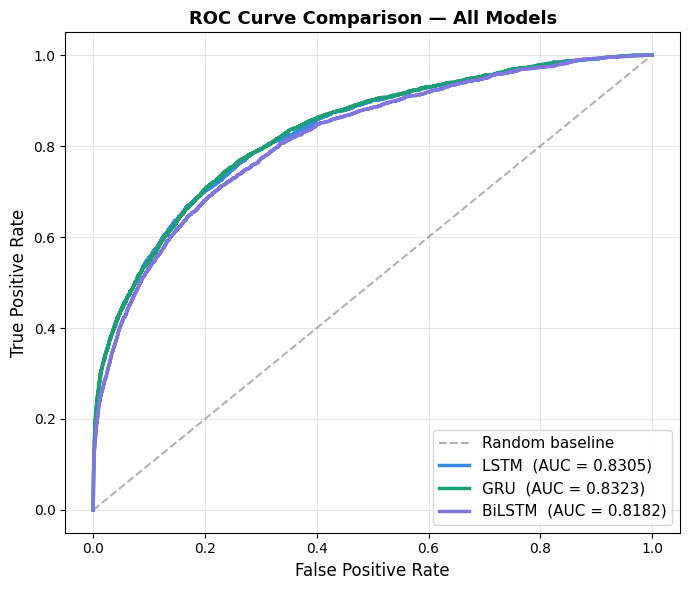

Saved: evaluation/roc_comparison.png


In [4]:
## ── 3. ROC curve overlay ──────────────────────────────────────────────────
colors = {'LSTM':'#378ADD', 'GRU':'#1D9E75', 'BiLSTM':'#7F77DD'}

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--', alpha=0.3, label='Random baseline')

for name, prob in y_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=colors[name], linewidth=2.5,
            label=f'{name}  (AUC = {auc:.4f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'roc_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: evaluation/roc_comparison.png")

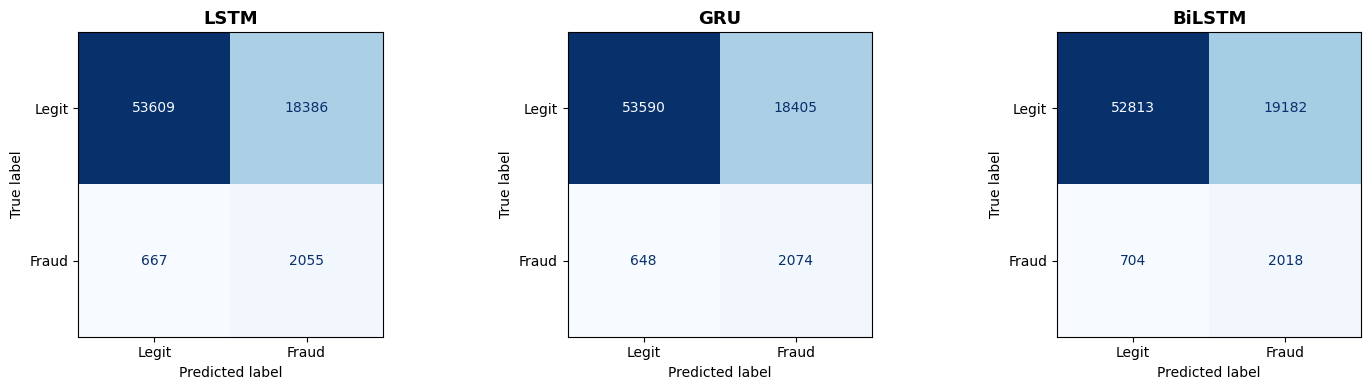

Saved: evaluation/confusion_matrices.png


In [5]:
## ── 4. Confusion matrices ─────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, y_preds.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: evaluation/confusion_matrices.png")

In [6]:
## ── 5. Comparison table ───────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

rows = []
for name in trained_models:
    m = all_metrics.get(name, {})
    rows.append({
        'Model'           : name,
        'AUC-ROC'         : m.get('auc_roc', round(roc_auc_score(y_test, y_probs[name]), 4)),
        'F1 (fraud)'      : m.get('f1',       round(f1_score(y_test, y_preds[name]), 4)),
        'Precision'       : m.get('precision', round(precision_score(y_test, y_preds[name]), 4)),
        'Recall'          : m.get('recall',    round(recall_score(y_test, y_preds[name]), 4)),
        'Parameters'      : m.get('n_params',  '—'),
        'Train time (min)': m.get('train_time_min', '—'),
    })

df_comp = pd.DataFrame(rows).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
df_comp.insert(0, 'Rank', range(1, len(df_comp)+1))
df_comp.to_csv(os.path.join(EVAL_DIR, 'comparison_results.csv'), index=False)

print(df_comp.to_string(index=False))
print("\nSaved: evaluation/comparison_results.csv")

 Rank  Model  AUC-ROC  F1 (fraud)  Precision  Recall  Parameters  Train time (min)
    1    GRU   0.8323      0.1788     0.1013  0.7619       25377              49.7
    2   LSTM   0.8305      0.1774     0.1005  0.7550       33313              47.3
    3 BiLSTM   0.8182      0.1687     0.0952  0.7414       83009              50.2

Saved: evaluation/comparison_results.csv


In [7]:
## ── 6. Best model selection & written justification ──────────────────────
best_model_name = df_comp.iloc[0]['Model']
best_auc        = df_comp.iloc[0]['AUC-ROC']
best_f1         = df_comp.iloc[0]['F1 (fraud)']

print(f"Best model : {best_model_name}")
print(f"AUC-ROC    : {best_auc}")
print(f"F1 (fraud) : {best_f1}")

report = f"""# FraudGuard — Evaluation Report

## Best Model: {best_model_name}

### Summary
The {best_model_name} model achieves the highest AUC-ROC of {best_auc} and F1 score of {best_f1}
on the held-out test set, making it the recommended model for the FraudGuard production deployment.

### Comparison Table
{df_comp.to_markdown(index=False)}

### Methodology
- All models trained on identical 70/15/15 train/val/test splits
- Same 15 features per timestep, same SEQ_LEN=5 window
- Same class weighting (computed from training set)
- Threshold tuned to 0.45 for maximum F1 on validation set
- Evaluated using AUC-ROC, F1, Precision, Recall, and parameter count

### Next Steps
- Deploy {best_model_name} in Streamlit app as the default model
- All three models are selectable in the live prediction page
- See evaluation/roc_comparison.png and evaluation/confusion_matrices.png
"""

with open(os.path.join(EVAL_DIR, 'report_summary.md'), 'w') as f:
    f.write(report)
print(report)
print("Saved: evaluation/report_summary.md")

Best model : GRU
AUC-ROC    : 0.8323
F1 (fraud) : 0.1788
# FraudGuard — Evaluation Report

## Best Model: GRU

### Summary
The GRU model achieves the highest AUC-ROC of 0.8323 and F1 score of 0.1788
on the held-out test set, making it the recommended model for the FraudGuard production deployment.

### Comparison Table
|   Rank | Model   |   AUC-ROC |   F1 (fraud) |   Precision |   Recall |   Parameters |   Train time (min) |
|-------:|:--------|----------:|-------------:|------------:|---------:|-------------:|-------------------:|
|      1 | GRU     |    0.8323 |       0.1788 |      0.1013 |   0.7619 |        25377 |               49.7 |
|      2 | LSTM    |    0.8305 |       0.1774 |      0.1005 |   0.755  |        33313 |               47.3 |
|      3 | BiLSTM  |    0.8182 |       0.1687 |      0.0952 |   0.7414 |        83009 |               50.2 |

### Methodology
- All models trained on identical 70/15/15 train/val/test splits
- Same 15 features per timestep, same SEQ_LEN=5 wind

## 7 · Solo Evaluator Contribution Notes
- Evaluator name: *(fill in)*  
- Observations about model differences: *(write)*  
- Recommendation and rationale: *(write)*  
- Lessons learned: *(write)*